In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("netflix_titles.csv")

df.head()
print("Rows and Columns:", df.shape)
df.info()
df.isnull().sum()
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Not Available", inplace=True)
df["country"].fillna("Unknown", inplace=True)
df["rating"].fillna("Not Rated", inplace=True)
df.drop_duplicates(inplace=True)


Rows and Columns: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


/tmp/ipykernel_7426/3469450428.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown", inplace=True)
/tmp/ipykernel_7426/3469450428.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

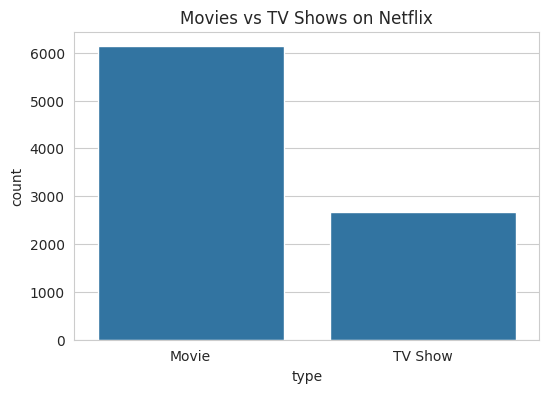

In [16]:
df["type"].value_counts()
plt.figure(figsize=(6,4))

sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


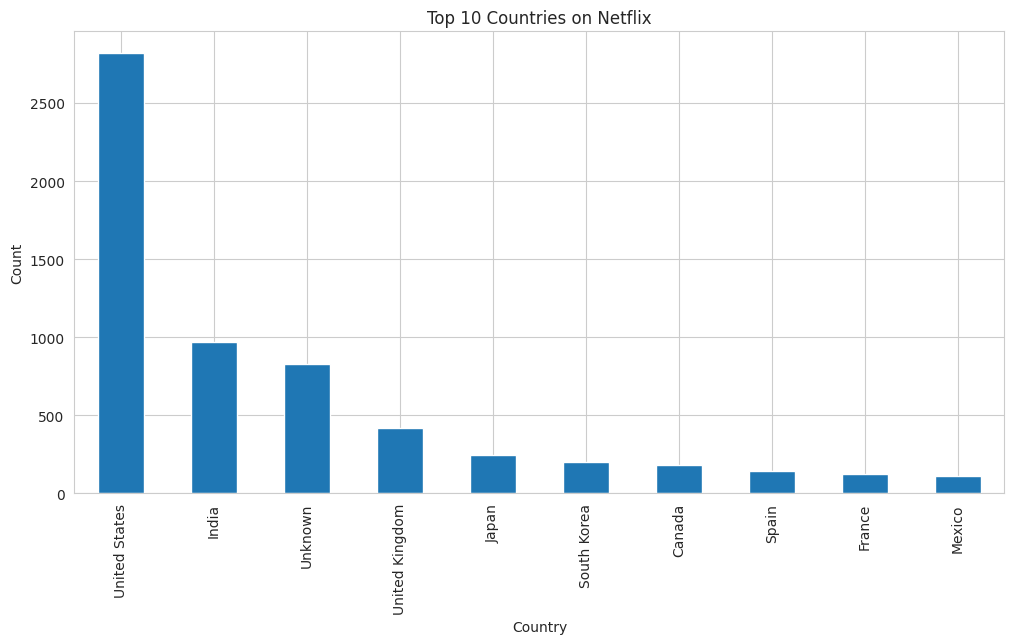

In [17]:
top_countries = df["country"].value_counts().head(10)

print(top_countries)
plt.figure(figsize=(12,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries on Netflix")

plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

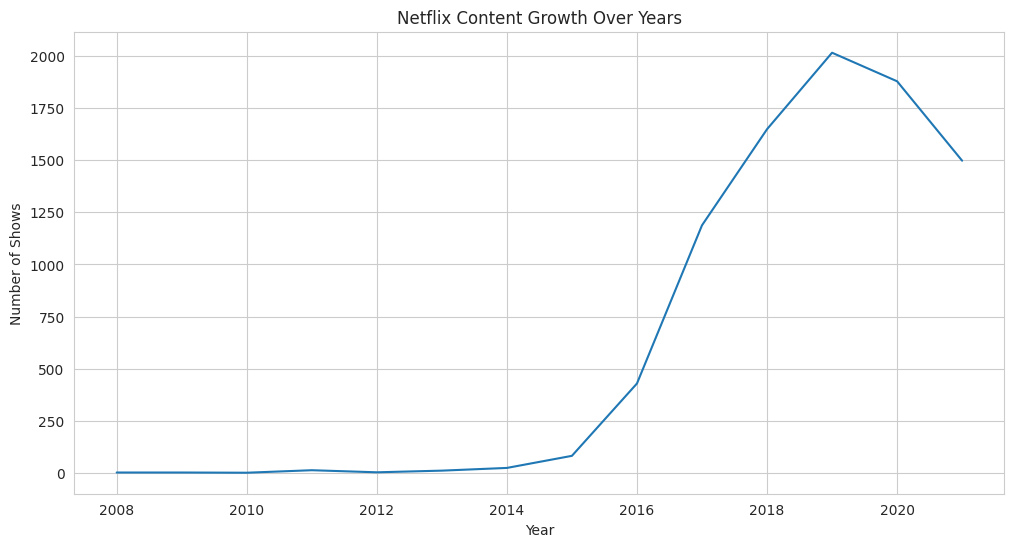

In [18]:
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed')
df["year_added"] = df["date_added"].dt.year
plt.figure(figsize=(12,6))

df["year_added"].value_counts().sort_index().plot()

plt.title("Netflix Content Growth Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.show()

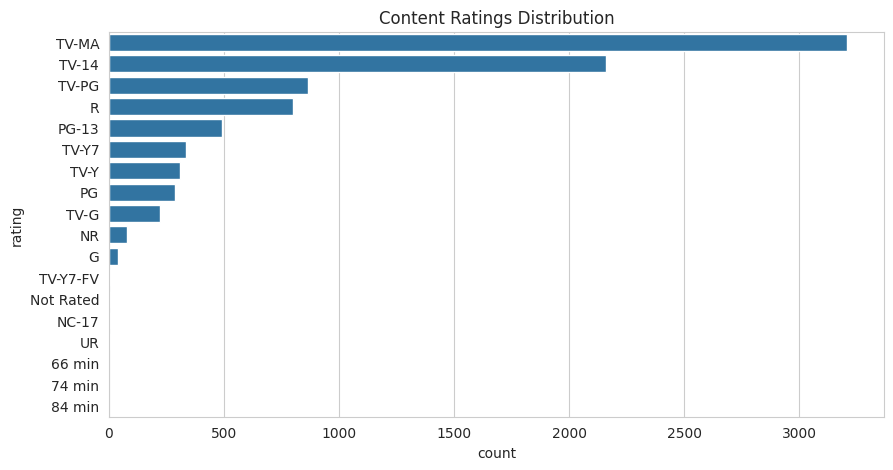

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(y="rating", data=df,
              order=df["rating"].value_counts().index)

plt.title("Content Ratings Distribution")

plt.show()

 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


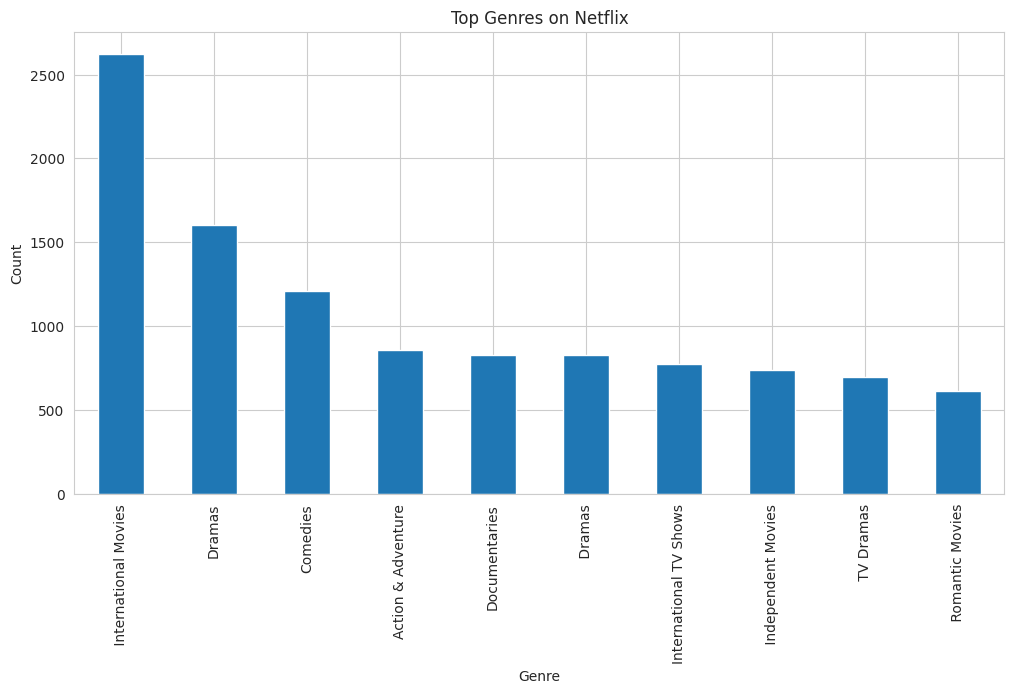

In [20]:
genres = df["listed_in"].str.split(",", expand=True)

genres.head()
all_genres = []

for col in genres.columns:
    all_genres.extend(genres[col].dropna())

genre_series = pd.Series(all_genres)

top_genres = genre_series.value_counts().head(10)

print(top_genres)
plt.figure(figsize=(12,6))

top_genres.plot(kind="bar")

plt.title("Top Genres on Netflix")

plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [21]:
with open("requirements.txt", "w") as f:
    f.write("""pandas
numpy
matplotlib
seaborn""")
    from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>